In [1]:
# import relevant libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

In [2]:
# load data from csv files into dataframes

marketing_data = pd.read_csv("marketing_data.csv")

marketing_data_dictionary = pd.read_csv("marketing_data_dictionary.csv")

In [3]:
# display the first few rows of the data

marketing_data.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,84835.0,0,0,2014-06-16,0,104,379,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,57091.0,0,0,2014-06-15,0,5,64,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,67267.0,0,1,2014-05-13,0,11,59,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,32474.0,1,1,2014-05-11,0,0,1,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,21474.0,1,0,2014-04-08,0,16,24,...,2,7,1,0,0,0,0,1,0,Spain


In [4]:
# display the data dictionary

marketing_data_dictionary

,Field,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Income,Customer's yearly household income
4,Kidhome,Number of children in customer's household
5,Teenhome,Number of teenagers in customer's household
6,Dt_Customer,Date of customer's enrollment with the company
7,Recency,Number of days since customer's last purchase
8,MntFruits,Amount spent on fruits in the last 2 years
9,MntMeatProducts,Amount spent on meat in the last 2 years


In [5]:
# calculate Q1 aka first quartile

q1 = marketing_data["Income"].quantile(0.25)
print("Q1:", q1)

# calculate Q3 aka third quartile

q3 = marketing_data["Income"].quantile(0.75)
print("Q3:", q3)

# calculate IQR aka inter quartile range

iqr = q3 - q1
print("IQR:", iqr)

# calculate lower limit

lower_limit = q1-1.5*iqr
print("lower limit:", lower_limit)

# calculate upper limit

upper_limit = q3+1.5*iqr
print("upper limit:", q3+1.5*iqr)

# identify outliers

outliers = marketing_data[(marketing_data["Income"] < lower_limit) | (marketing_data["Income"] > upper_limit)]
print("outliers:")
outliers

Q1: 34722.0
Q3: 68289.75
IQR: 33567.75
lower limit: -15629.625
upper limit: 118641.375
outliers:


,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
325,4931,1977,Graduation,157146.0,0,0,2013-04-29,13,0,1725,...,0,1,0,0,0,0,0,0,0,Saudi Arabia
497,1501,1982,PhD,160803.0,0,0,2012-08-04,21,16,1622,...,1,0,0,0,0,0,0,0,0,USA
527,9432,1977,Graduation,666666.0,1,0,2013-06-02,23,14,18,...,3,6,0,0,0,0,0,0,0,Saudi Arabia
731,1503,1976,PhD,162397.0,1,1,2013-06-03,31,1,16,...,1,1,0,0,0,0,0,0,0,Spain
853,5336,1971,Master,157733.0,1,0,2013-06-04,37,1,9,...,1,1,0,0,0,0,0,0,0,Spain
1826,5555,1975,Graduation,153924.0,0,0,2014-02-07,81,1,1,...,0,0,0,0,0,0,0,0,0,Spain
1925,11181,1949,PhD,156924.0,0,0,2013-08-29,85,1,2,...,0,0,0,0,0,0,0,0,0,Canada
2204,8475,1973,PhD,157243.0,0,1,2014-03-01,98,2,1582,...,0,0,0,0,0,0,0,0,0,India


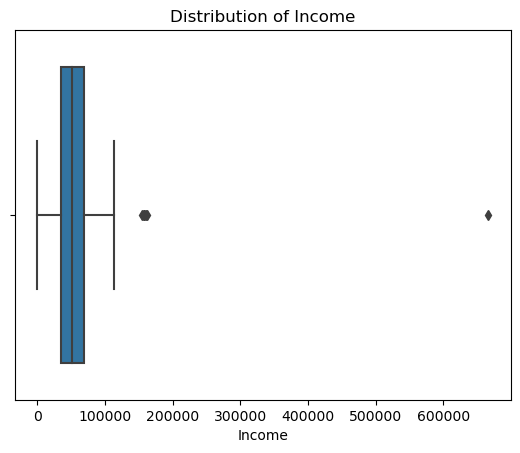

In [6]:
# create boxplot

sns.boxplot(x="Income", data=marketing_data)

# add title

plt.title("Distribution of Income")

# show plot

plt.show()

In [7]:
# winsorize the Income values to address the outliers

marketing_data["Income"] = winsorize(marketing_data["Income"], limits=[0.01, 0.01])

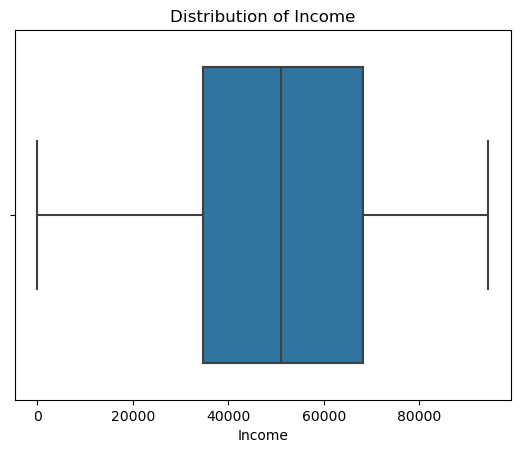

In [8]:
# create boxplot

sns.boxplot(x="Income", data=marketing_data)

# add title

plt.title("Distribution of Income")

# show plot

plt.show()